# Fig. 2D, 2E, Extended Data Fig. 3 - Pathway Enrichment Venn and Bars

**Figure 2D**: Venn diagram of significantly enriched Reactome pathways (FDR < 0.25) comparing ground-truth (GT) and predicted (Pred) perturbation responses, with hypergeometric test for overlap significance.

**Figure 2E**: Top 10 common enriched pathways between GT and Pred, shown as grouped horizontal bar charts with Jaccard similarity.

**Extended Data Fig. 3**: Combined Venn grid across all drugs.

---

## Method

For each drug, we:
1. Compute mean expression deltas: `GT = mean(target) - mean(source)`, `Pred = mean(transport) - mean(source)`
2. Select the top 300 genes by absolute delta magnitude for both GT and Pred
3. Run [Enrichr](https://maayanlab.cloud/Enrichr/) ORA on each gene list against Reactome 2022
4. Identify significantly enriched pathways (FDR < 0.25)
5. Visualize pathway overlap via Venn diagrams with hypergeometric p-values
6. Plot top 10 common pathways as grouped bar charts with Jaccard similarity

Individual Venn and bar plots are shown only for `PLOT_DRUG` (default: trametinib). The combined Venn grid shows all drugs.

## Required Input: Prediction CSVs

This notebook expects CSV files at `logs/id_preds/id_predictions_model_*.csv` containing columns:
- `dtype`: one of `"source"`, `"target"`, `"trans"` (transported/predicted)
- `condition`: drug-dose string, e.g. `"givinostat-10000"`
- `model_ood_drug`: identifier for the OOD model
- Remaining columns: gene expression features (indexed by position)

### How to generate these CSVs

These prediction files are produced by running inference with a trained Conditional Monge Gap model. Typical workflow:

```python
# 1. Train the model (or load a checkpoint)
from scripts.train import train_conditional_monge
train_conditional_monge(
    drug="trametinib", ood="10000",
    config_path="configs/monge-sciplex.yml",
    logger_path=Path("logs/"),
)

# 2. After training, use trainer.transport() to get predictions
transport = trainer.transport(source_batch, condition_embedding, num_contexts)

# 3. Save source, target, and transport arrays into a CSV with dtype/condition columns
```

Alternatively, if you have a saved checkpoint:
```python
trainer.load_checkpoint(path="path/to/checkpoint")
# Then run transport as above
```

The CSV should have one row per cell, with `dtype` indicating whether it is a source, target, or transported cell. Only conditions ending in `-10000` (highest dose) are used for pathway analysis.

## Additional requirements

```
pip install gseapy matplotlib-venn
```

In [1]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Adjust these paths and parameters before running.

ADATA_PATH = "../data/scrna-sciplex3/hvg.h5ad"
PREDICTIONS_GLOB = "../logs/id_preds/id_predictions_model_*.csv"
OUTPUT_DIR = "../logs/reactome_id_pathways_venn_bars"

ENRICHR_LIBRARY = "Reactome_2022"
TOP_K_GENES = 300        # Number of top DE genes to submit to Enrichr
FDR_THRESHOLD = 0.25     # Adjusted p-value cutoff for significant pathways
TOP_N_COMMON = 10        # Number of top common pathways to plot
DOSE_SUFFIX = "-10000"   # Only analyze this dose level
VENN_GRID_COLS = 3       # Columns in the combined Venn grid
PLOT_DRUG = "trametinib"  # Only show individual venn/bar plots for this drug

## Imports

In [2]:
import os
import glob
import math
from pathlib import Path
from time import sleep

import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn2
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

## Helper Functions

In [3]:
def hypergeom_pathway_overlap(gt_set: set, pred_set: set, universe_size: int) -> float:
    """Hypergeometric test for significance of pathway overlap.
    
    Returns the survival-function p-value: P(X >= observed overlap).
    """
    overlap = len(gt_set & pred_set)
    if overlap == 0:
        return 1.0
    return hypergeom.sf(overlap - 1, universe_size, len(gt_set), len(pred_set))


def safe_enrichr(gene_list: list, library: str, max_retries: int = 5) -> gp.enrichr:
    """Run Enrichr with retries to handle transient API failures."""
    for attempt in range(max_retries):
        try:
            sleep(2)
            return gp.enrichr(
                gene_list=gene_list,
                gene_sets=library,
                organism="human",
                outdir=None,
                no_plot=True,
            )
        except Exception as e:
            print(f"  Enrichr error (attempt {attempt + 1}/{max_retries}): {e}")
            sleep(5)
    raise RuntimeError(f"Enrichr API failed after {max_retries} retries.")

## Plotting Functions

In [4]:
def plot_venn(gt_set: set, pred_set: set, drug: str, hyper_p: float, universe_size: int):
    """Plot a single Venn diagram for GT vs Pred pathway overlap."""
    fig, ax = plt.subplots(figsize=(7, 6))
    venn2([gt_set, pred_set], set_labels=["GT", "Pred"], ax=ax)
    ax.set_title(f"Pathway overlap: {drug}", fontsize=14, pad=20)

    legend_text = f"Hypergeom P: {hyper_p:.1e}  |  Total Pathways: {universe_size}"
    handle = mpatches.Patch(color="none", label=legend_text)
    ax.legend(handles=[handle], loc="upper center", bbox_to_anchor=(0.5, -0.05),
              frameon=False, fontsize=10)
    plt.subplots_adjust(bottom=0.15)
    plt.show()


def plot_venn_grid(venn_entries: list, n_cols: int = 3):
    """Plot all drug Venn diagrams in a combined grid."""
    if not venn_entries:
        return
    n_rows = math.ceil(len(venn_entries) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 6))
    axes = np.atleast_1d(axes).flatten()

    for idx, ax in enumerate(axes):
        if idx >= len(venn_entries):
            ax.axis("off")
            continue
        drug, gt_set, pr_set, hyper_p, universe_size = venn_entries[idx]
        venn2([gt_set, pr_set], set_labels=["GT", "Pred"], ax=ax)
        ax.set_title(drug, fontweight="bold", fontsize=11, pad=10)
        metrics_text = f"p={hyper_p:.1e}, n={universe_size}"
        ax.text(0.5, -0.08, metrics_text, ha="center", va="top", fontsize=8,
                transform=ax.transAxes)

    plt.tight_layout(pad=3.0, h_pad=4.0)
    plt.show()


def plot_common_pathways(gt_df: pd.DataFrame, pr_df: pd.DataFrame, drug: str, top_n: int = 10):
    """Plot top common enriched pathways as a grouped horizontal bar chart."""
    gt_top = set(gt_df.nsmallest(top_n, "Adjusted P-value")["Term"])
    pr_top = set(pr_df.nsmallest(top_n, "Adjusted P-value")["Term"])
    union_len = len(gt_top | pr_top)
    jaccard = len(gt_top & pr_top) / union_len if union_len > 0 else 0.0

    merged = pd.merge(gt_df, pr_df, on="Term", suffixes=("_gt", "_pr"))
    merged["score_gt"] = -np.log10(merged["Adjusted P-value_gt"])
    merged["score_pr"] = -np.log10(merged["Adjusted P-value_pr"])
    plot_data = merged.sort_values("score_gt", ascending=False).head(top_n)

    if len(plot_data) == 0:
        print(f"  No common pathways found for {drug}")
        return

    # Truncate long pathway names
    max_label_len = 50
    labels = [t[:max_label_len] + "..." if len(t) > max_label_len else t
              for t in plot_data["Term"]]

    fig, ax = plt.subplots(figsize=(12, max(5, len(plot_data) * 0.8)))
    y = np.arange(len(plot_data))
    h = 0.35

    ax.barh(y - h / 2, plot_data["score_gt"], h, label="GT", color="salmon", alpha=0.9)
    ax.barh(y + h / 2, plot_data["score_pr"], h, label="Pred", color="skyblue", alpha=0.9)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("-log10(FDR)")
    ax.legend(loc="lower right")
    ax.set_title(f"Top Common Pathways: {drug}\nJaccard(Top {top_n} GT vs Pred): {jaccard:.3f}",
                 fontsize=13)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## Load Data and Compute Deltas

In [5]:
# Load gene symbols from the reference AnnData
adata = sc.read_h5ad(ADATA_PATH)
idx_to_symbol = dict(enumerate(adata.var["gene_short_name"]))
print(f"Loaded {len(idx_to_symbol)} gene symbols from {ADATA_PATH}")

# Discover prediction CSVs
csv_files = sorted(glob.glob(PREDICTIONS_GLOB))
if not csv_files:
    raise FileNotFoundError(
        f"No prediction CSVs found at '{PREDICTIONS_GLOB}'.\n"
        "See the overview above for how to generate them."
    )
print(f"Found {len(csv_files)} prediction file(s)")

# Aggregate mean deltas per drug (highest dose only)
drug_data = {}
for file_path in csv_files:
    df = pd.read_csv(file_path, index_col=0)
    metadata_cols = {"dtype", "condition", "model_ood_drug"}
    feature_cols = [c for c in df.columns if c not in metadata_cols]

    for cond in df["condition"].unique():
        if not cond.endswith(DOSE_SUFFIX):
            continue
        drug = cond.split("-")[0]
        subset = df[df["condition"] == cond]

        src = subset[subset["dtype"] == "source"][feature_cols].values
        tgt = subset[subset["dtype"] == "target"][feature_cols].values
        trn = subset[subset["dtype"] == "trans"][feature_cols].values

        if min(len(src), len(tgt), len(trn)) == 0:
            continue

        drug_data.setdefault(drug, {"gt": [], "pred": []})
        drug_data[drug]["gt"].append(tgt.mean(0) - src.mean(0))
        drug_data[drug]["pred"].append(trn.mean(0) - src.mean(0))

print(f"Aggregated deltas for {len(drug_data)} drug(s): {', '.join(sorted(drug_data))}")

Loaded 1000 gene symbols from ../data/scrna-sciplex3/hvg.h5ad
Found 9 prediction file(s)
Aggregated deltas for 9 drug(s): abexinostat, belinostat, dacinostat, entinostat, givinostat, mocetinostat, pracinostat, tacedinaline, trametinib


## Run Enrichr and Plot Per-Drug Results

Enrichr ORA is run for **all** drugs (results stored for the grid), but individual Venn and bar plots are only shown for the drug specified by `PLOT_DRUG`.

────────────────────────────────────────────────────────────
abexinostat
  GT sig: 97, Pred sig: 173, overlap: 86, hypergeom p: 8.54e-48
────────────────────────────────────────────────────────────
belinostat
  GT sig: 99, Pred sig: 148, overlap: 74, hypergeom p: 3.80e-36
────────────────────────────────────────────────────────────
dacinostat
  GT sig: 113, Pred sig: 174, overlap: 90, hypergeom p: 1.62e-40
────────────────────────────────────────────────────────────
entinostat
  GT sig: 63, Pred sig: 147, overlap: 52, hypergeom p: 4.82e-26
────────────────────────────────────────────────────────────
givinostat
  GT sig: 57, Pred sig: 171, overlap: 46, hypergeom p: 5.63e-20
────────────────────────────────────────────────────────────
mocetinostat
  GT sig: 61, Pred sig: 136, overlap: 39, hypergeom p: 2.04e-14
────────────────────────────────────────────────────────────
pracinostat
  GT sig: 94, Pred sig: 145, overlap: 67, hypergeom p: 9.15e-30
───────────────────────────────────────────

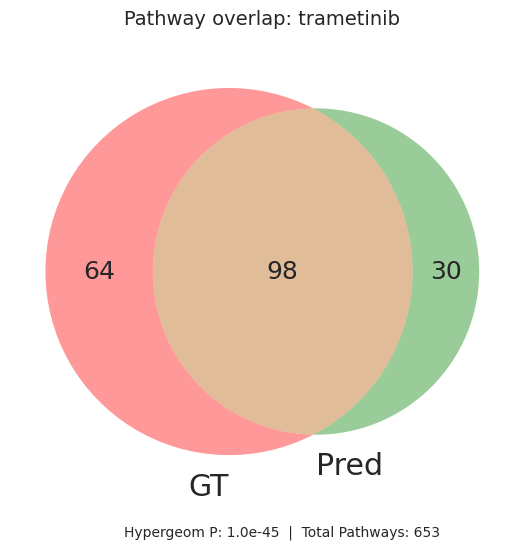

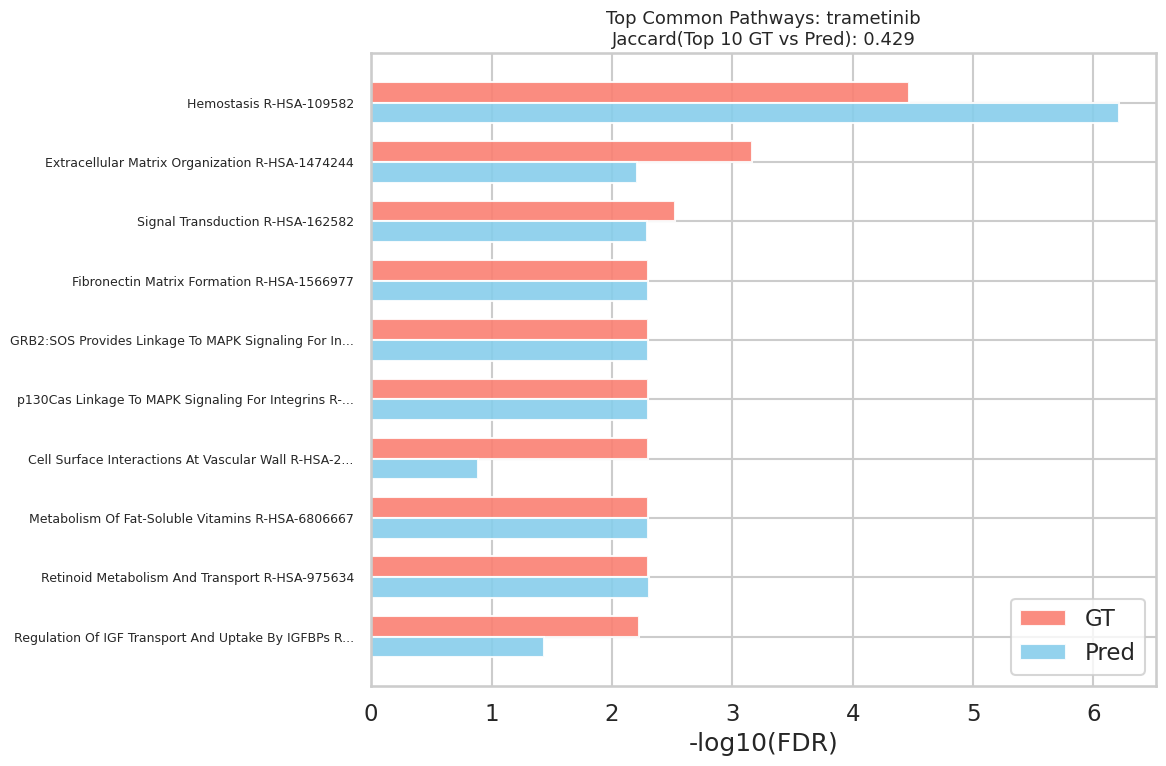

In [6]:
venn_entries = []

for drug in sorted(drug_data):
    data = drug_data[drug]
    print(f"{'─' * 60}\n{drug}")

    mean_gt = np.mean(data["gt"], axis=0)
    mean_pr = np.mean(data["pred"], axis=0)
    genes = [idx_to_symbol[i] for i in range(len(mean_gt))]

    # Top genes by absolute delta
    gt_top_genes = (
        pd.Series(mean_gt, index=genes)
        .abs()
        .sort_values(ascending=False)
        .head(TOP_K_GENES)
        .index.tolist()
    )
    pr_top_genes = (
        pd.Series(mean_pr, index=genes)
        .abs()
        .sort_values(ascending=False)
        .head(TOP_K_GENES)
        .index.tolist()
    )

    # Enrichr ORA
    enr_gt = safe_enrichr(gt_top_genes, ENRICHR_LIBRARY)
    enr_pr = safe_enrichr(pr_top_genes, ENRICHR_LIBRARY)
    gt_enriched = enr_gt.results
    pr_enriched = enr_pr.results

    # Significant pathways
    gt_sig = set(gt_enriched.loc[gt_enriched["Adjusted P-value"] < FDR_THRESHOLD, "Term"])
    pr_sig = set(pr_enriched.loc[pr_enriched["Adjusted P-value"] < FDR_THRESHOLD, "Term"])
    hyper_p = hypergeom_pathway_overlap(gt_sig, pr_sig, universe_size=len(gt_enriched))

    print(f"  GT sig: {len(gt_sig)}, Pred sig: {len(pr_sig)}, "
          f"overlap: {len(gt_sig & pr_sig)}, hypergeom p: {hyper_p:.2e}")

    venn_entries.append((drug, gt_sig, pr_sig, hyper_p, len(gt_enriched)))

    # Only show individual plots for the selected drug
    if drug == PLOT_DRUG:
        plot_venn(gt_sig, pr_sig, drug, hyper_p, len(gt_enriched))
        plot_common_pathways(gt_enriched, pr_enriched, drug, top_n=TOP_N_COMMON)

## Combined Venn Grid

All drugs in a single figure for comparison.

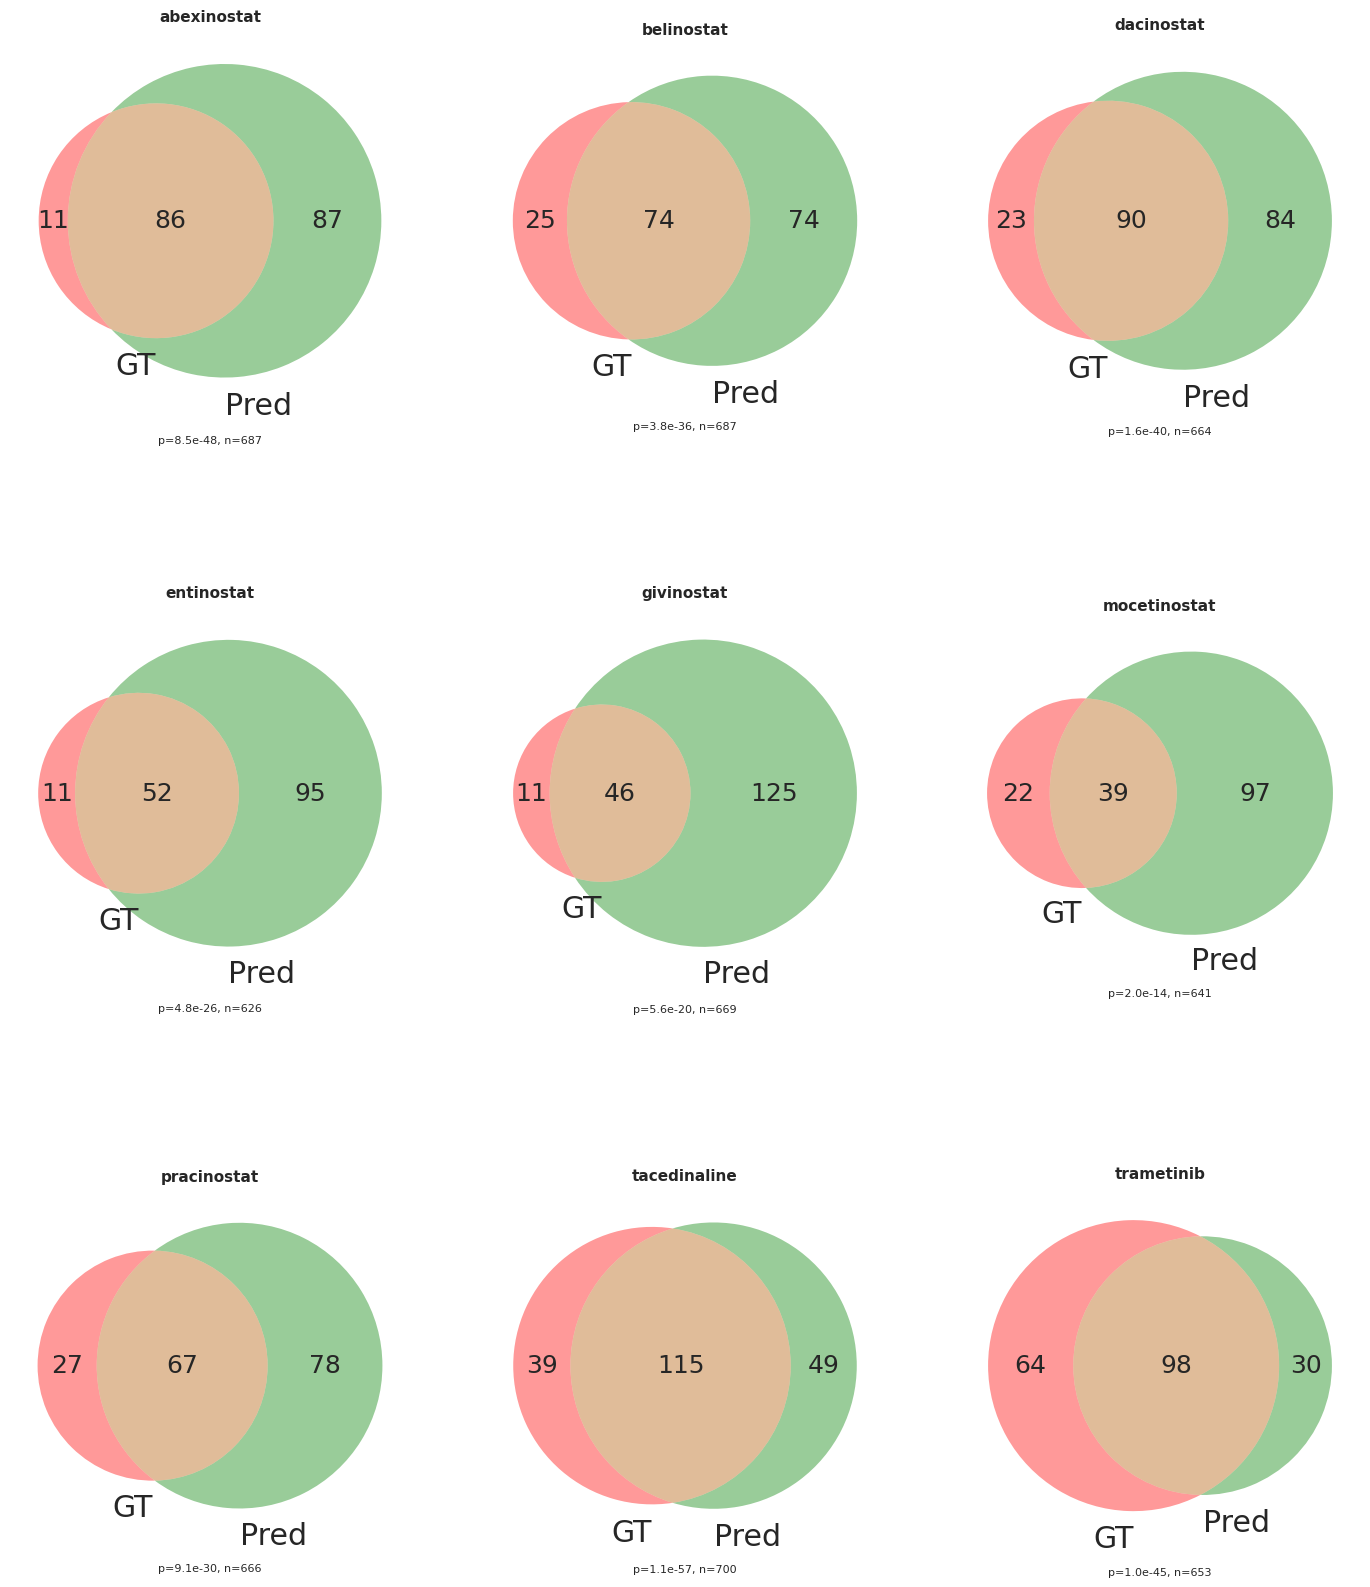

In [7]:
plot_venn_grid(venn_entries, n_cols=VENN_GRID_COLS)